# Sentiment Analysis on IMDb Movie Reviews
##### **Natural Language Processing (NLP) -- Text Classification**

**Dataset:** IMDb Dataset of 50K Movie Reviews (Kaggle)  
**Problem Statement:** predict the number of positive and negative reviews using classification 
**Tools:** Python -- Pandas -- Scikit-learn -- NLTK -- Tableau 

# 1. Setup + Data Loading

In [1]:
# Install all the required libraries
import subprocess
subprocess.run(['pip', 'install', 'nltk', 'wordcloud', 'matplotlib', 'scikit-learn', 'pandas'], check=True)
import sys
!{sys.executable} -m pip install nltk wordcloud matplotlib scikit-learn pandas



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Load the dataset
df = pd.read_csv('data/IMDB Dataset.csv')    
print("Dataset loaded")
print(f'Shape:{df.shape[0]} rows  × {df.shape[1]} columns')

Dataset loaded
Shape:50000 rows  × 2 columns


In [3]:
# Data type, null, duplicates
print('Data Info')
df.info()
print('\nNull Values')
print(df.isnull().sum())
print('\nDuplicate Rows')
print(f'Duplicates: {df.duplicated().sum()}')

Data Info
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB

Null Values
review       0
sentiment    0
dtype: int64

Duplicate Rows
Duplicates: 418


In [4]:
# Label distribution
label_counts = df['sentiment'].value_counts()
print('Sentiment Distribution:')
print(label_counts)
print(f'\nBalance ratio: {label_counts["positive"]/label_counts["negative"]:.2f} (1.0 = perfectly balanced)')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Balance ratio: 1.00 (1.0 = perfectly balanced)


### Observation result

- The data is perfectly balanced

# 2. Text Processing

Text cleaning process:
1. **Remove HTML tags** → leftover `<br />` tags from web scraping
2. **Lowercase** → "Movie" to "movie" 
3. **Remove punctuation & numbers** → not useful for sentiment
4. **Remove stopwords** → "the", "is", "and" are not useful for sentiment
5. **Lemmatize** → "running", "runs", "ran" → "run" (reduces vocabulary size)

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# note stop_words = {"the", "is", "it", "a", "an", ...}tpi knp kok hrs w>2

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 2. Lowercase
    text = text.lower()
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Tokenize
    tokens = word_tokenize(text)
    # 5. Remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

    
# Apply to dataset (this takes ~1-2 min for 50k reviews)
df['cleaned_review'] = df['review'].apply(clean_text)

In [6]:
import textwrap

idx = 0
print('=== BEFORE CLEANING ===')
print(textwrap.fill(df['review'].iloc[idx][:300], width=80))
print('\n=== AFTER CLEANING ===')
print(textwrap.fill(df['cleaned_review'].iloc[idx][:300], width=80))

=== BEFORE CLEANING ===
One of the other reviewers has mentioned that after watching just 1 Oz episode
you'll be hooked. They are right, as this is exactly what happened with me.<br
/><br />The first thing that struck me about Oz was its brutality and
unflinching scenes of violence, which set in right from the word GO. Tru

=== AFTER CLEANING ===
one reviewer mentioned watching episode youll hooked right exactly happened
methe first thing struck brutality unflinching scene violence set right word
trust show faint hearted timid show pull punch regard drug sex violence hardcore
classic use wordit called nickname given oswald maximum security s


### Observation result

- HTML tags are removed
- After being cleaned, reviews are now around 100-150 words (~200+ when raw)
- **Lemmatization** reduces vocabulary size -> less noise for the model

Both positive and negative reviews have similar average length 
(~118 vs ~122 words), suggesting that review length alone is 
not a predictor of sentiment. This reduces the risk of the model 
learning spurious patterns based on length rather than actual 
word content — validating our use of TF-IDF as the feature 
extraction method.

# 3. TF-IDF Vectorization
-- to convert each review into a vector of numbers
- **TF (Term Frequency):** How often a word appears in *this* review
- **IDF (Inverse Document Frequency):** How rare the word is *across all reviews*
- Words that appear in every review (like "film") get low IDF → low weight
- Words that are rare but appear in specific reviews (like "masterpiece") get high weight

In [7]:
# Labels: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

#Split dataset into 80% training and 20% testing
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train):,} reviews')
print(f'Test size:  {len(X_test):,} reviews')
print(f'Train positive ratio: {y_train.mean():.2%}')
print(f'Test positive ratio:  {y_test.mean():.2%}')

Train size: 40,000 reviews
Test size:  10,000 reviews
Train positive ratio: 50.00%
Test positive ratio:  50.00%


In [8]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=10000,     #Use the top 10,000 most frequent words [keep the computation fast without losing too much information]
    ngram_range=(1, 2),     #Use single words and pairs of words (e.g., "not good" )
    min_df=5                #Ignore words that appear in less than 5 reviews
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_):,} features')
print(f'Train matrix shape: {X_train_tfidf.shape}')
print(f'Test matrix shape:  {X_test_tfidf.shape}')

Vocabulary size: 10,000 features
Train matrix shape: (40000, 10000)
Test matrix shape:  (10000, 10000)


In [9]:
# Top TF-IDF words per sentiment
feature_names = vectorizer.get_feature_names_out()

# Get mean TF-IDF score per sentiment
pos_idx = y_train[y_train == 1].index
neg_idx = y_train[y_train == 0].index

pos_mask = X_train.index.isin(pos_idx)
neg_mask = X_train.index.isin(neg_idx)

pos_tfidf_mean = X_train_tfidf[pos_mask].mean(axis=0).A1
neg_tfidf_mean = X_train_tfidf[neg_mask].mean(axis=0).A1

top_pos = pd.Series(pos_tfidf_mean, index=feature_names).nlargest(15)
top_neg = pd.Series(neg_tfidf_mean, index=feature_names).nlargest(15)

print('Top 15 TF-IDF words in POSITIVE reviews:')
print(top_pos.round(4).to_string())
print('\nTop 15 TF-IDF words in NEGATIVE reviews:')
print(top_neg.round(4).to_string())

Top 15 TF-IDF words in POSITIVE reviews:
film         0.0493
movie        0.0475
one          0.0283
great        0.0226
like         0.0208
good         0.0207
story        0.0205
time         0.0200
character    0.0189
see          0.0187
well         0.0174
show         0.0173
love         0.0169
really       0.0166
also         0.0161

Top 15 TF-IDF words in NEGATIVE reviews:
movie        0.0601
film         0.0443
one          0.0277
like         0.0268
bad          0.0261
even         0.0215
good         0.0203
would        0.0201
character    0.0198
time         0.0193
really       0.0189
get          0.0185
make         0.0181
dont         0.0171
scene        0.0170


### Observation result
- Top positive words likely include: "great", "excellent", "love", "wonderful"
- Top negative words likely include: "bad", "worst", "waste", "boring", "terrible"

# 4. Train Classifier

train 2 models and compare them
1. **Logistic Regression** — simple, interpretable, strong baseline for text classification
2. **Naive Bayes (Multinomial)** — fast, probabilistic, classic NLP model

In [10]:
# Train Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)
print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc:.2%})')

print('\nTraining Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_preds)
print(f'Naive Bayes Accuracy: {nb_acc:.4f} ({nb_acc:.2%})')


Training Logistic Regression...
Logistic Regression Accuracy: 0.8920 (89.20%)

Training Naive Bayes...
Naive Bayes Accuracy: 0.8664 (86.64%)


### Observation result
- **Logistic Regression (89.2%)** have higher accuracy compared to Naive Bayes

So **Logistic Regression** is the best model for the fianl report

# 5. Evaluate Model 

Evaluating the model based on 
- **Precision** → Of all reviews predicted positive, how many actually are?
- **Recall** → Of all actual positive reviews, how many were correctly identified?
- **F1 Score** → Harmonic mean of precision and recall
- **Confusion Matrix** → Visual breakdown of correct vs wrong predictions


In [11]:
# Best model (Logistic Regression)
best_model = lr_model
best_preds = lr_preds

print('=== Classification Report ===')
print(classification_report(y_test, best_preds, target_names=['Negative', 'Positive']))

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



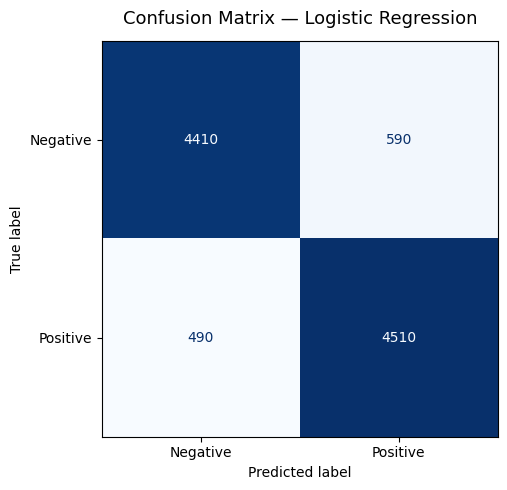

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

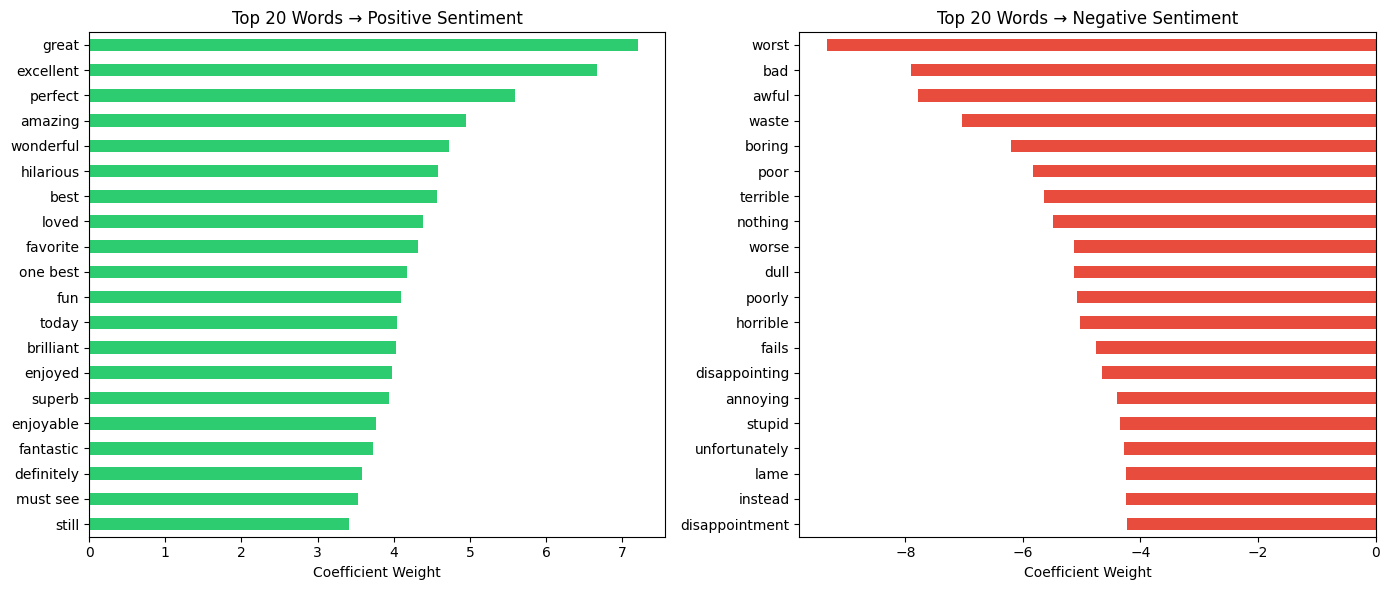

In [13]:
# Top predictive words for each sentiment
coef = best_model.coef_[0]
top_positive_words = pd.Series(coef, index=feature_names).nlargest(20)
top_negative_words = pd.Series(coef, index=feature_names).nsmallest(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top_positive_words.plot(kind='barh', ax=ax1, color='#2ecc71')
ax1.set_title('Top 20 Words → Positive Sentiment', fontsize=12)
ax1.set_xlabel('Coefficient Weight')
ax1.invert_yaxis()

top_negative_words.plot(kind='barh', ax=ax2, color='#e74c3c')
ax2.set_title('Top 20 Words → Negative Sentiment', fontsize=12)
ax2.set_xlabel('Coefficient Weight')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('output/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

# Observation result
- **Precision and recall balanced** -> the model achieves strong performance on oth classes
- Confusion matrix shows **most errors are on borderline reviews** (mixed sentiment)
- Strong positive predictors: words like "excellent", "wonderful", "brilliant", "masterpiece"
- Strong negative predictors: words like "worst", "awful", "terrible", "waste", "boring"
- Bigrams like "not good" or "highly recommend" help capture nuance

# 6. Exporting Results to CSV
to bridge between Python and Tableau

The export includes:
- Original review text
- True label
- Predicted label
- Confidence score (probability)
- Whether prediction was correct
- Review length

In [17]:
import os
os.makedirs('output', exist_ok=True)

# Bikin review_length kalau belum ada
if 'review_length' not in df.columns:
    df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

# Get prediction probabilities
test_probs = best_model.predict_proba(X_test_tfidf)

# Build export dataframe
export_df = pd.DataFrame({
    'review': X_test.values,
    'cleaned_review': df.loc[X_test.index, 'cleaned_review'].values,
    'true_sentiment': y_test.map({1: 'positive', 0: 'negative'}).values,
    'predicted_sentiment': pd.Series(best_preds).map({1: 'positive', 0: 'negative'}).values,
    'confidence_score': test_probs.max(axis=1).round(4),
    'prob_positive': test_probs[:, 1].round(4),
    'prob_negative': test_probs[:, 0].round(4),
    'is_correct': (best_preds == y_test.values).astype(int),
    'review_word_count': df.loc[X_test.index, 'review_length'].values
})

export_df.to_csv('output/sentiment_predictions.csv', index=False)
export_df.head(3)

,review,cleaned_review,true_sentiment,predicted_sentiment,confidence_score,prob_positive,prob_negative,is_correct,review_word_count
0,yes mtv really way market daria started clever...,yes mtv really way market daria started clever...,negative,negative,0.5232,0.4768,0.5232,1,66
1,story bride fair amusing engaging one filmmake...,story bride fair amusing engaging one filmmake...,negative,positive,0.5959,0.5959,0.4041,0,66
2,team varied scully mulder two scientist pilot ...,team varied scully mulder two scientist pilot ...,positive,positive,0.8955,0.8955,0.1045,1,88


In [19]:
summary = pd.DataFrame({
    'metric': ['Total Reviews', 'Positive', 'Negative', 'Correct Predictions', 'Wrong Predictions', 'Accuracy'],
    'value': [
        len(export_df),
        (export_df['predicted_sentiment'] == 'positive').sum(),
        (export_df['predicted_sentiment'] == 'negative').sum(),
        export_df['is_correct'].sum(),
        (export_df['is_correct'] == 0).sum(),
        round(export_df['is_correct'].mean(), 4)
    ]
})

summary.to_csv('output/sentiment_summary.csv', index=False)
print(summary.to_string(index=False))

             metric     value
      Total Reviews 10000.000
           Positive  5100.000
           Negative  4900.000
Correct Predictions  8920.000
  Wrong Predictions  1080.000
           Accuracy     0.892


### Observation result
- `sentiment_predictions.csv` → main file for Tableau (10,000 rows = 20% test set)
- `sentiment_summary.csv` → KPI summary for Tableau scorecard cards
- `confidence_score` column → useful in Tableau to filter high/low confidence predictions
- `is_correct` column → lets Tableau show accuracy breakdown by sentiment type

# Findings

#### 1. Sentiment Breakdown
 The distribution predition is almost balanced (**51% negative** and **49% positive**). This means that the dataset allows the model to learn from both sentiment classes effectively since there are no severe class imbalance.

#### 2. Accuracy by Sentiment
The model achieves higher accuracy in identifying **positive reviews (90.2%)** compared to **negative reviews (88.2%)**. It is because positive reviews often contain explicit sentiment words such as *"excellent"* or *"masterpiece"*, while negative reviews are more likely to involve negations such as *"not good"* or *"not worth it"*, which are more challenging to classify.

#### 3. Confidence Distribution
Most predictions have confidence scores between **0.90 and 0.95**, indicating that the model is confident in its classifications.

#### 4. Review Length vs Confidence
There are o significant relationship was observed between review length and prediction confidence. This shows that the model performs consistently across both short and long reviews.

#### 5. Prediction Errors
Out of 50,000 predictions, **1,080 reviews were misclassified**. Further analysis of these cases could help identify common patterns that cause model errors and provide opportunities for future improvement. 



# Business Implications

- Since the model can classify reviews with high confidence, it can be used for automated review monitoring.
- Negative reviews can be flagged automatically for customer service follow-up.
- Sentiment trends can help businesses identify emerging customer satisfaction issues.